# **Scenario:**
You are analyzing sensor data from a manufacturing plant's assembly line.
The machinery has various settings (categorical) and outputs continuous sensor
readings (temperature, vibration, RPM). The plant manager wants a dual-purpose tool:
one that predicts the internal temperature of a machine to prevent overheating, and
another that classifies whether a manufactured part will pass or fail quality inspection
based on those same machine conditions.
# **The Problem Statement:**
Using an industrial sensor dataset, build a machine learning
pipeline using scikit-learn that predicts a continuous metric (e.g., machine
temperature) using multivariable regression. Additionally, build a logistic regression
classifier to predict a binary outcome (e.g., product failure). You must handle categorical
machine settings, properly split your data, research the impact of gradient descent
learning rates using standard library tools, and save the final models for future
deployment.

In [2]:
import pandas as pd
data=pd.read_csv('/content/Smart Factory Machinery Predictor dataset.csv')
df=pd.DataFrame(data)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Task 1: Simple Linear Regression


### Task 1: Simple Linear Regression

**The Goal:** Establish the baseline of predictive modeling.
**The Action:** Start with a clean subset of the factory data. Train a simple linear regression model to predict the machine's internal `Air temperature [K]` using just a single continuous variable, such as `Rotational speed [rpm]`.
**The Research:** Plot the line of best fit and calculate the Mean Squared Error (MSE) to establish a baseline performance.

Mean Squared Error (Simple Linear Regression): 3.9986


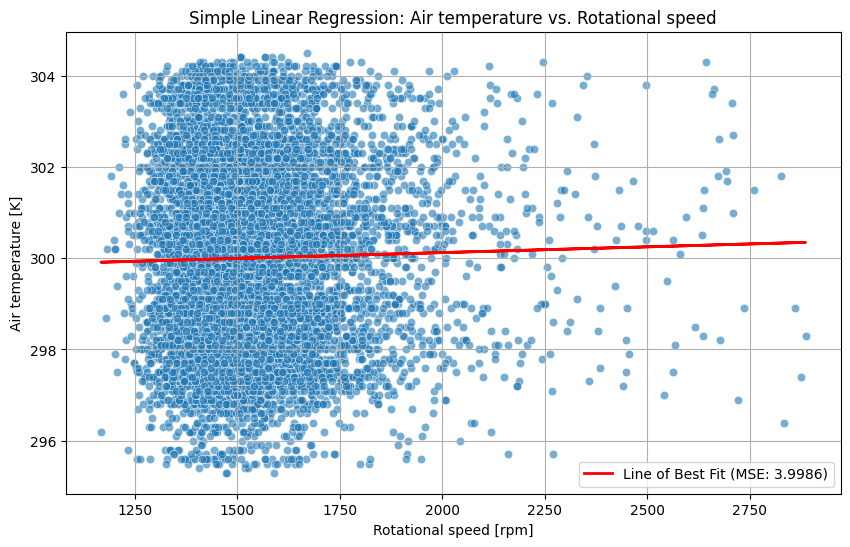

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

X = df[['Rotational speed [rpm]']]
y = df['Air temperature [K]']

model_simple = LinearRegression()
model_simple.fit(X, y)

# Make predictions
y_pred_simple = model_simple.predict(X)

# Calculate Mean Squared Error (MSE)
mse_simple = mean_squared_error(y, y_pred_simple)
print(f"Mean Squared Error (Simple Linear Regression): {mse_simple:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rotational speed [rpm]', y='Air temperature [K]', data=df, alpha=0.6)
plt.plot(X, y_pred_simple, color='red', linewidth=2, label=f'Line of Best Fit (MSE: {mse_simple:.4f})')
plt.title('Simple Linear Regression: Air temperature vs. Rotational speed')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Air temperature [K]')
plt.legend()
plt.grid(True)
plt.show()

### Task 2: Multivariable Regression

**The Goal:** Introduce complexity and multi-dimensional data.
**The Action:** Upgrade the model to predict `Air temperature [K]` using multiple continuous variables simultaneously (e.g., `Rotational speed [rpm]`, `Torque [Nm]`, and `Process temperature [K]`).
**The Research:** Compare the MSE of this new model against the simple model from Task 1. Document why adding more relevant features usually (but not always) reduces the error rate.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_multi = df[['Rotational speed [rpm]', 'Torque [Nm]', 'Process temperature [K]']]
y = df['Air temperature [K]']

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# Make predictions
y_pred_multi = model_multi.predict(X_multi)

# Calculate Mean Squared Error (MSE)
mse_multi = mean_squared_error(y, y_pred_multi)
print(f"Mean Squared Error (Multivariable Linear Regression): {mse_multi:.4f}")

print(f"Simple Linear Regression MSE: {mse_simple:.4f}")
print(f"Difference in MSE: {mse_simple - mse_multi:.4f}")

Mean Squared Error (Multivariable Linear Regression): 0.9295
Simple Linear Regression MSE: 3.9986
Difference in MSE: 3.0690


### Task 3: Save Model

**The Goal:** Bridge the gap between a local script and a deployable asset.
**The Action:** Take the best-performing multivariable model from the previous step and serialize it to the hard drive using libraries like `pickle` or `joblib`.
**The Research:** Write a short script in a separate file to load this saved model and predict the temperature for a mock "new" machine reading. This proves the model is detached from the training environment.

In [6]:
import joblib
import os

model_filename = 'multivariable_temperature_model.joblib'

joblib.dump(model_multi, model_filename)
print(f"Model saved to {model_filename}")

print("\n--- Demonstrating model loading and prediction ---")

loaded_model = joblib.load(model_filename)
print(f"Model loaded from {model_filename}")

mock_new_reading = pd.DataFrame([{
    'Rotational speed [rpm]': 1500,
    'Torque [Nm]': 45.0,
    'Process temperature [K]': 309.0
}])

print(f"\nMock new machine reading:\n{mock_new_reading}")

predicted_temperature = loaded_model.predict(mock_new_reading)

print(f"Predicted Air temperature [K] for the mock reading: {predicted_temperature[0]:.2f}")


Model saved to multivariable_temperature_model.joblib

--- Demonstrating model loading and prediction ---
Model loaded from multivariable_temperature_model.joblib

Mock new machine reading:
   Rotational speed [rpm]  Torque [Nm]  Process temperature [K]
0                    1500         45.0                    309.0
Predicted Air temperature [K] for the mock reading: 298.82


### Task 4: One-Hot Encoding

**The Goal:** Learn to handle real-world, non-numeric factory data.
**The Action:** Introduce a categorical column to the dataset (e.g., "Type" which has 'L', 'M', 'H' for Low, Medium, High quality products). Use encoding techniques to convert these text labels into binary columns (1s and 0s) so a machine learning algorithm can process them.
**The Research:** Explain the "Dummy Variable Trap" and why one column is often dropped after encoding.

In [7]:
import pandas as pd

print("Original 'Type' column unique values:")
print(df['Type'].unique())

df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True)

print("\nDataFrame after One-Hot Encoding (first 5 rows):")
display(df_encoded.head())

Original 'Type' column unique values:
['M' 'L' 'H']

DataFrame after One-Hot Encoding (first 5 rows):


,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


### Task 5: Train-Test Split

**The Goal:** Prevent the model from merely memorizing the data (overfitting).
**The Action:** Take the newly encoded, complex dataset and strictly divide it (e.g., 80% for training, 20% for testing) before feeding it to any algorithm.
**The Research:** Train a new multivariable model on the 80% split and test it on the 20%. Document why evaluating a model on the exact same data it was trained on is a critical failure in data science.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df_encoded[['Rotational speed [rpm]', 'Torque [Nm]', 'Process temperature [K]', 'Type_L', 'Type_M']]
y = df_encoded['Air temperature [K]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

model_split = LinearRegression()
model_split.fit(X_train, y_train)

y_train_pred = model_split.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"\nMean Squared Error on Training Set: {mse_train:.4f}")

y_test_pred = model_split.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error on Test Set: {mse_test:.4f}")


Training set size: 8000 samples
Testing set size: 2000 samples

Mean Squared Error on Training Set: 0.9195
Mean Squared Error on Test Set: 0.9696


### Task 6: Logistic Regression

**The Goal:** Shift from predicting a continuous number to predicting a distinct category.
**The Action:** Using the properly split and encoded dataset, train a Logistic Regression classifier to predict a binary outcome: 1 if a manufactured part will be Defective, and 0 if it will be Good.
**The Research:** Generate a Confusion Matrix for the test set predictions. Analyze the real-world factory cost of a False Positive (throwing away a good part) versus a False Negative (shipping a broken part to a customer).

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X_clf = df_encoded[['Rotational speed [rpm]', 'Torque [Nm]', 'Process temperature [K]', 'Type_L', 'Type_M']]
y_clf = df_encoded['Machine failure']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Classification Training set size: {X_train_clf.shape[0]} samples")
print(f"Classification Testing set size: {X_test_clf.shape[0]} samples")

model_logistic = LogisticRegression(solver='liblinear', random_state=42)
model_logistic.fit(X_train_clf, y_train_clf)


y_pred_clf = model_logistic.predict(X_test_clf)

conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)
print("\n--- Confusion Matrix ---")
print(conf_matrix)

tn, fp, fn, tp = conf_matrix.ravel()
print(f"\nTrue Negatives (Correctly predicted good parts): {tn}")
print(f"False Positives (Good parts incorrectly predicted as defective): {fp}")
print(f"False Negatives (Defective parts incorrectly predicted as good): {fn}")
print(f"True Positives (Correctly predicted defective parts): {tp}")

print("\n--- Classification Report ---")
print(classification_report(y_test_clf, y_pred_clf))

Classification Training set size: 8000 samples
Classification Testing set size: 2000 samples

--- Confusion Matrix ---
[[1938    1]
 [  47   14]]

True Negatives (Correctly predicted good parts): 1938
False Positives (Good parts incorrectly predicted as defective): 1
False Negatives (Defective parts incorrectly predicted as good): 47
True Positives (Correctly predicted defective parts): 14

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.93      0.23      0.37        61

    accuracy                           0.98      2000
   macro avg       0.95      0.61      0.68      2000
weighted avg       0.98      0.98      0.97      2000

